In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Mục tiêu bước này:
Sử dụng các biểu đồ để trực quan hóa các chỉ số biến động, xu hướng, tăng mạnh, giảm mạnh, và các yếu tố khác.
Hiển thị xu hướng của các chỉ số này trong các nhóm biến động (dựa trên cột target).
So sánh 2 mã cổ phiếu tác động lên nhau

In [2]:
files = [
    ("META", "data/META/META_processed.csv"),
    ("RDDT", "data/RDDT/RDDT_processed.csv")
]


===== TRỰC QUAN HÓA CHO META =====


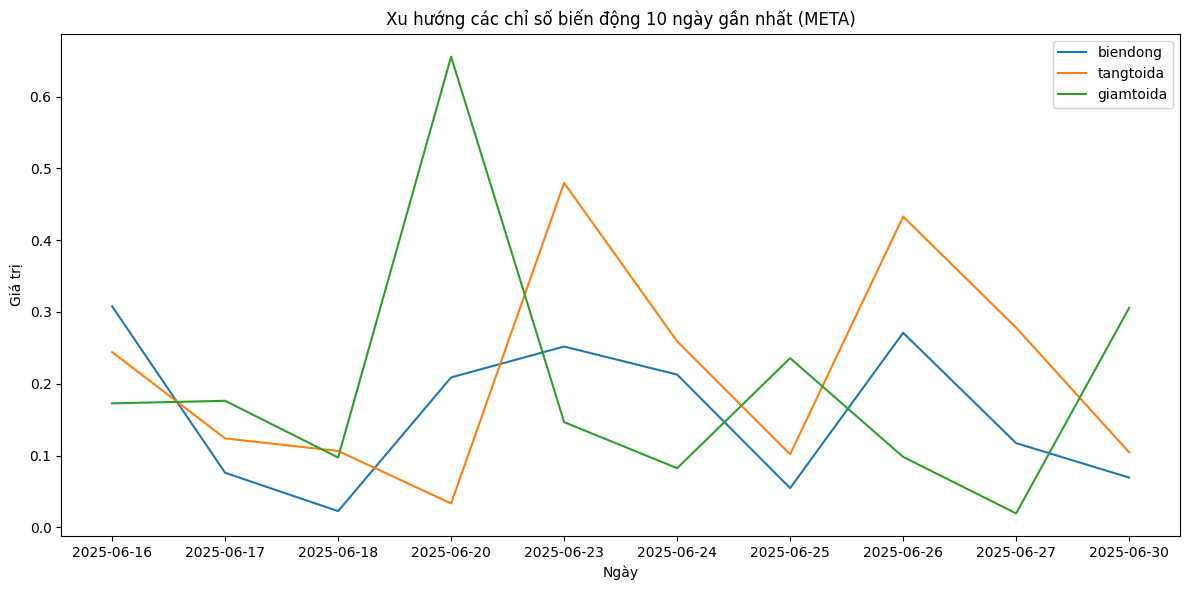

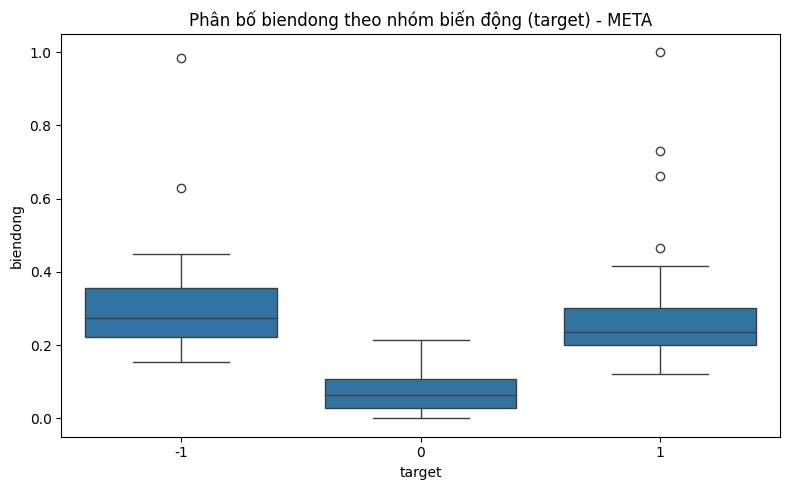

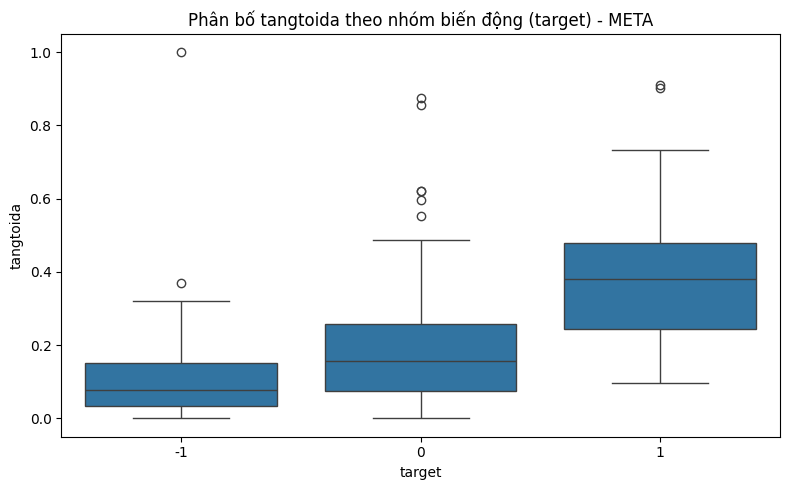

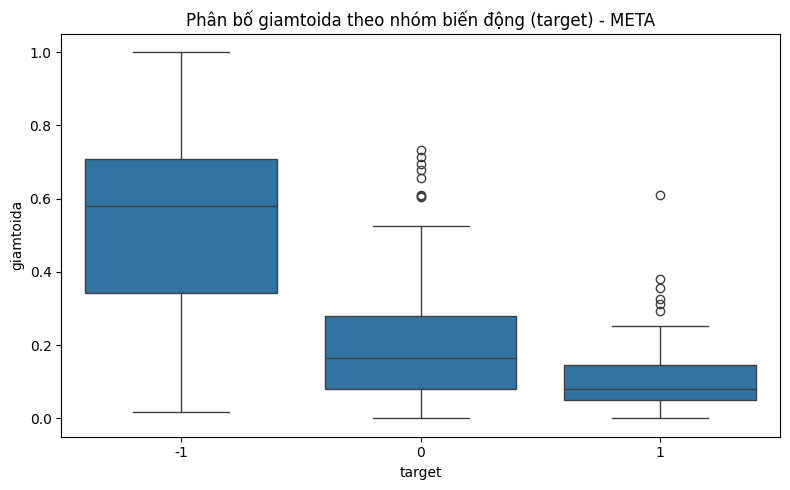

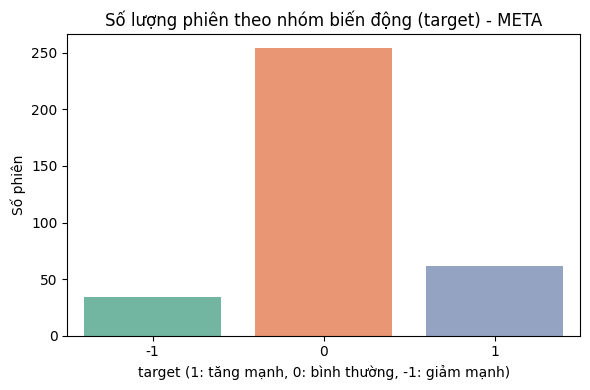

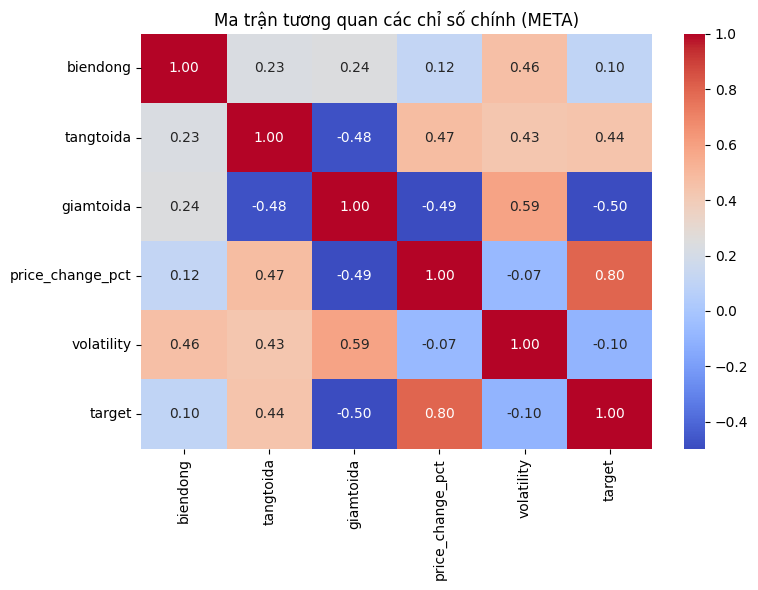

Đã lưu các biểu đồ vào chart\5_visualization\META

===== TRỰC QUAN HÓA CHO RDDT =====


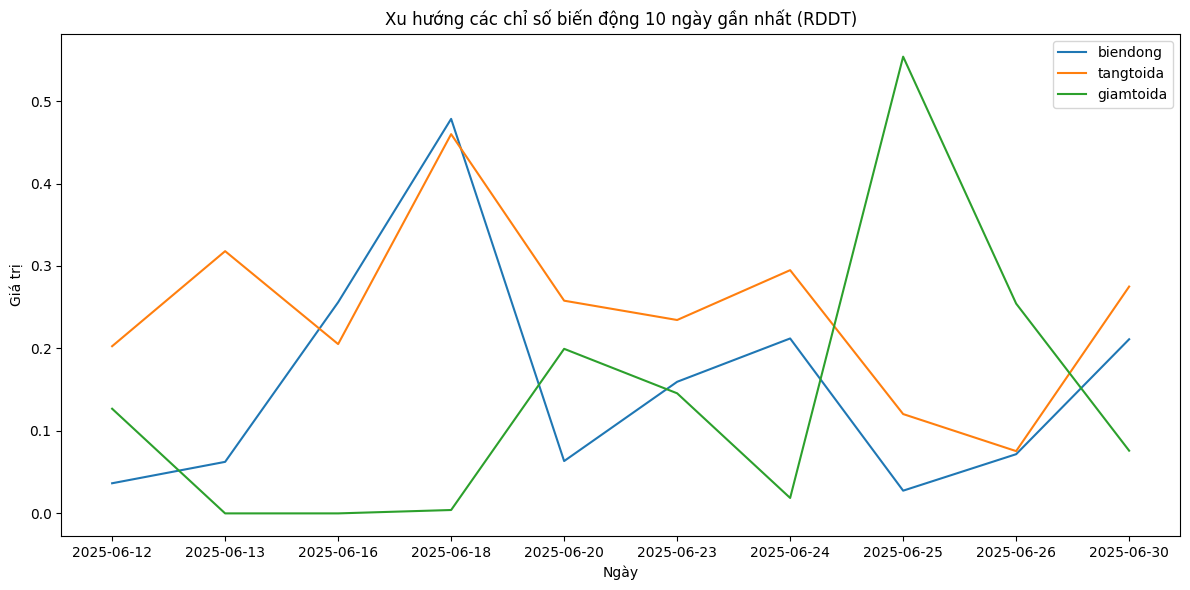

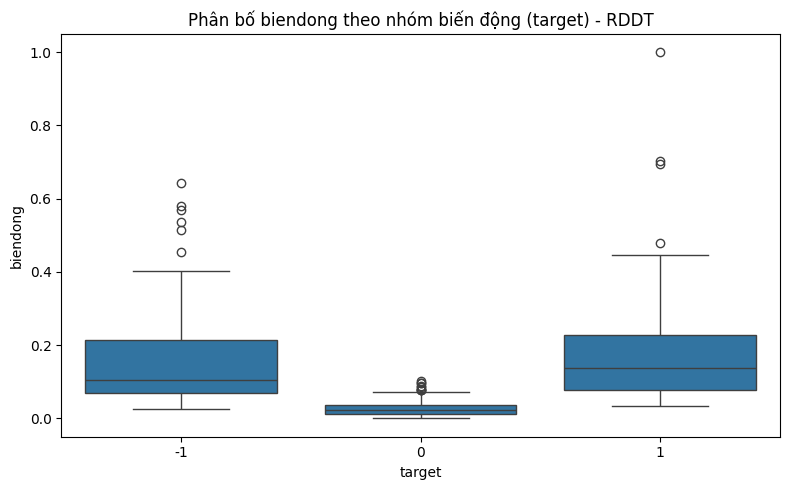

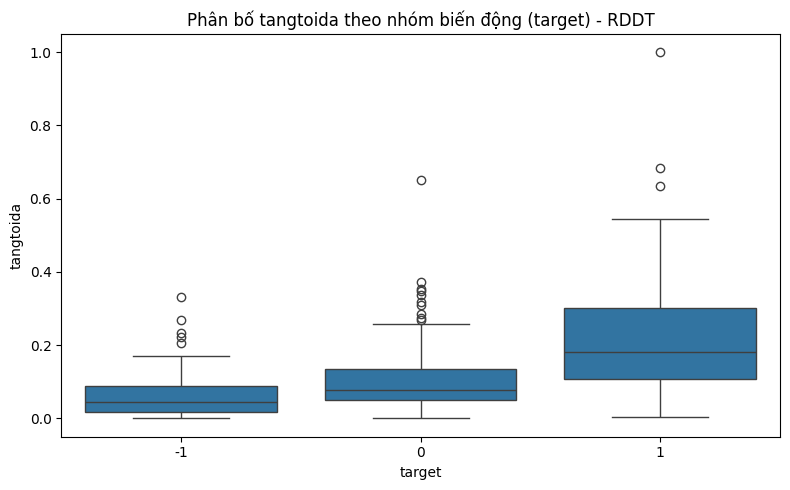

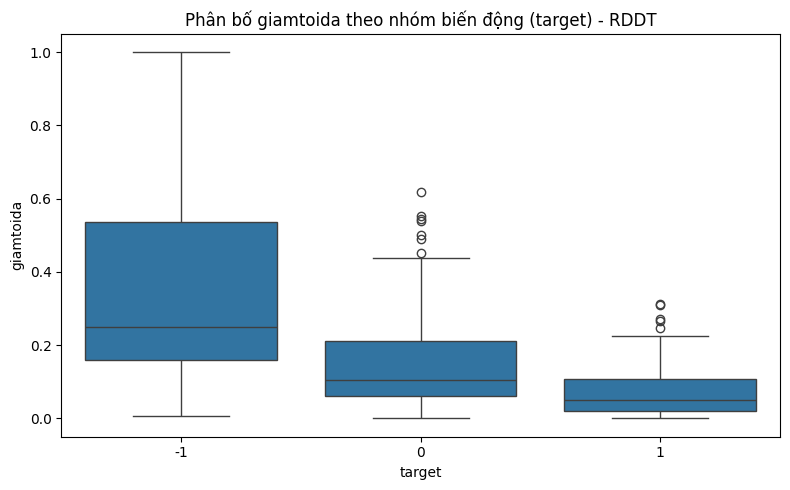

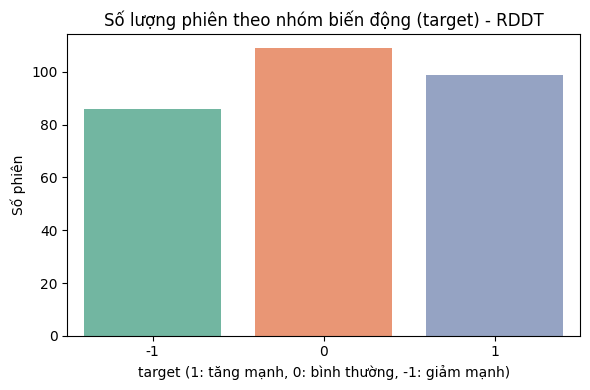

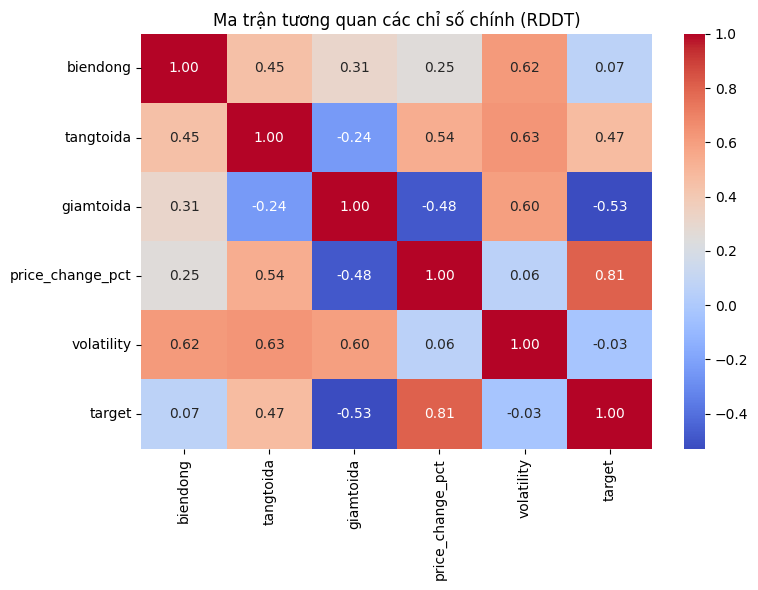

Đã lưu các biểu đồ vào chart\5_visualization\RDDT


In [3]:
for ticker, file_path in files:
    print(f"\n===== TRỰC QUAN HÓA CHO {ticker} =====")
    df = pd.read_csv(file_path, index_col=0)
    chart_dir = os.path.join("chart", "5_visualization", ticker)
    os.makedirs(chart_dir, exist_ok=True)

    # 1. Line plot: Xu hướng các chỉ số biến động theo thời gian (10 ngày gần nhất)
    plt.figure(figsize=(12, 6))
    last_10 = df.tail(10)
    for col in ['biendong', 'tangtoida', 'giamtoida']:
        if col in last_10.columns:
            plt.plot(last_10.index, last_10[col], label=col)
    plt.title(f"Xu hướng các chỉ số biến động 10 ngày gần nhất ({ticker})")
    plt.xlabel("Ngày")
    plt.ylabel("Giá trị")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(chart_dir, "line_biendong_tang_giam.png"))
    plt.show()
    plt.close()

    # 2. Boxplot: So sánh phân bố các chỉ số biến động theo nhóm target
    for col in ['biendong', 'tangtoida', 'giamtoida']:
        if col in df.columns and 'target' in df.columns:
            plt.figure(figsize=(8, 5))
            sns.boxplot(x='target', y=col, data=df)
            plt.title(f"Phân bố {col} theo nhóm biến động (target) - {ticker}")
            plt.tight_layout()
            plt.savefig(os.path.join(chart_dir, f"boxplot_{col}_by_target.png"))
            plt.show()
            plt.close()

    # 3. Bar plot: Số lượng phiên tăng mạnh, giảm mạnh, bình thường
    if 'target' in df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x='target', data=df, palette='Set2', hue='target', legend=False)
        plt.title(f"Số lượng phiên theo nhóm biến động (target) - {ticker}")
        plt.xlabel("target (1: tăng mạnh, 0: bình thường, -1: giảm mạnh)")
        plt.ylabel("Số phiên")
        plt.tight_layout()
        plt.savefig(os.path.join(chart_dir, "bar_count_target.png"))
        plt.show()
        plt.close()

    # 4. Heatmap: Ma trận tương quan giữa các chỉ số chính
    plt.figure(figsize=(8, 6))
    corr_cols = [c for c in ['biendong', 'tangtoida', 'giamtoida', 'price_change_pct', 'volatility', 'target'] if c in df.columns]
    corr = df[corr_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f"Ma trận tương quan các chỉ số chính ({ticker})")
    plt.tight_layout()
    plt.savefig(os.path.join(chart_dir, "heatmap_corr.png"))
    plt.show()
    plt.close()

    print(f"Đã lưu các biểu đồ vào {chart_dir}")

In [4]:
# ================= SO SÁNH VÀ DỰ BÁO 2 MÃ =================
# Ghép hai file processed theo ngày
meta = pd.read_csv("data/META/META_processed.csv", index_col=0)
rddt = pd.read_csv("data/RDDT/RDDT_processed.csv", index_col=0)
meta = meta.reset_index().rename(columns={"index": "Date"})
rddt = rddt.reset_index().rename(columns={"index": "Date"})
merged = pd.merge(meta, rddt, left_on="Date", right_on="Date", suffixes=("_META", "_RDDT"))
# Chỉ lấy 10 ngày cuối cùng để vẽ các biểu đồ so sánh
merged_10 = merged.tail(10)
compare_dir = os.path.join("chart", "5_visualization", "compare")
os.makedirs(compare_dir, exist_ok=True)

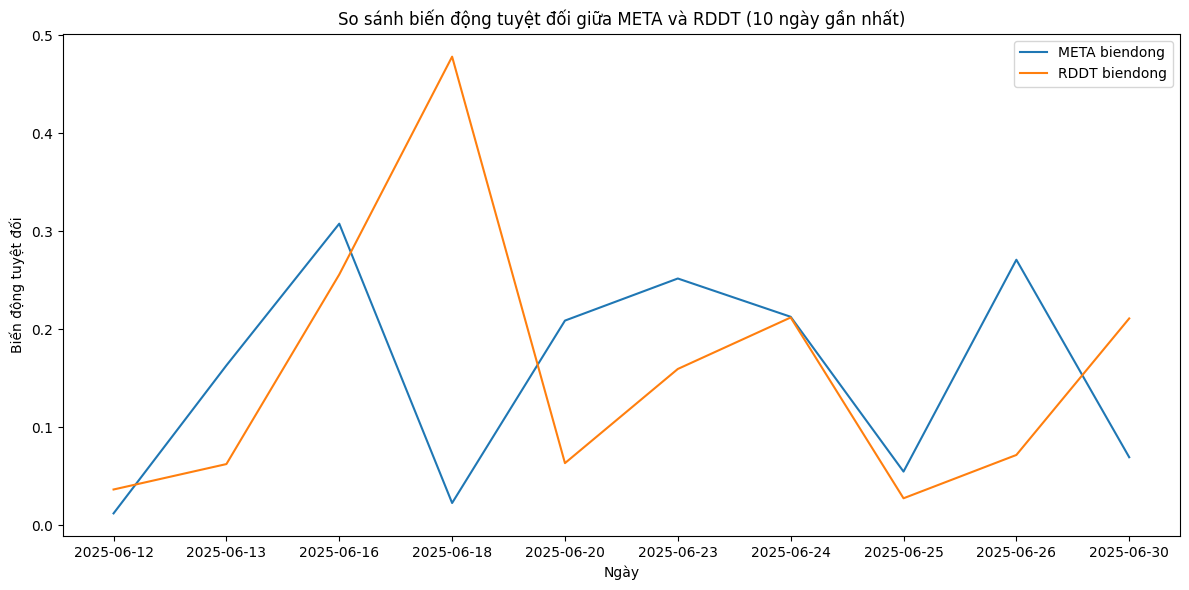

In [5]:
# 1. Line plot song song biến động (biendong)
plt.figure(figsize=(12, 6))
plt.plot(merged_10["Date"], merged_10["biendong_META"], label="META biendong")
plt.plot(merged_10["Date"], merged_10["biendong_RDDT"], label="RDDT biendong")
plt.title("So sánh biến động tuyệt đối giữa META và RDDT (10 ngày gần nhất)")
plt.xlabel("Ngày")
plt.ylabel("Biến động tuyệt đối")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(compare_dir, "line_biendong_compare.png"))
plt.show()
plt.close()

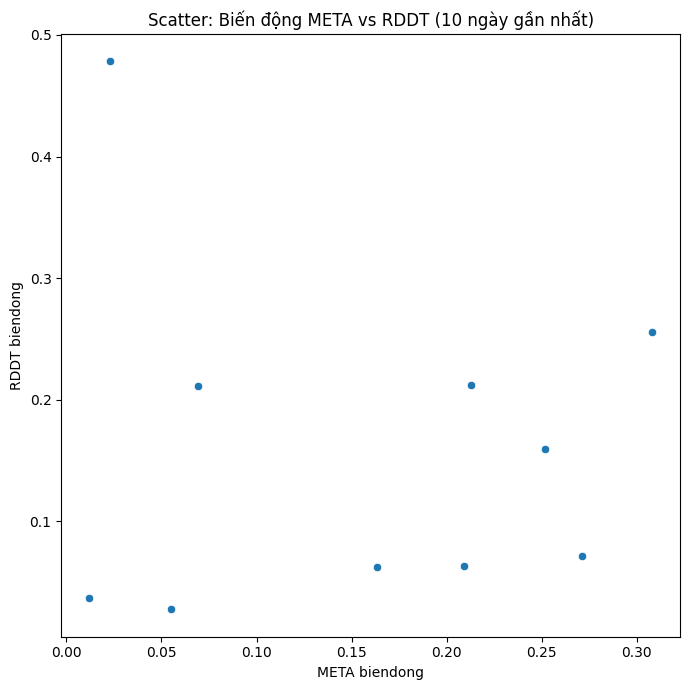

In [6]:
# 2. Scatter plot giữa biến động hai mã
plt.figure(figsize=(7, 7))
sns.scatterplot(x="biendong_META", y="biendong_RDDT", data=merged_10)
plt.title("Scatter: Biến động META vs RDDT (10 ngày gần nhất)")
plt.xlabel("META biendong")
plt.ylabel("RDDT biendong")
plt.tight_layout()
plt.savefig(os.path.join(compare_dir, "scatter_biendong_META_vs_RDDT.png"))
plt.show()
plt.close()

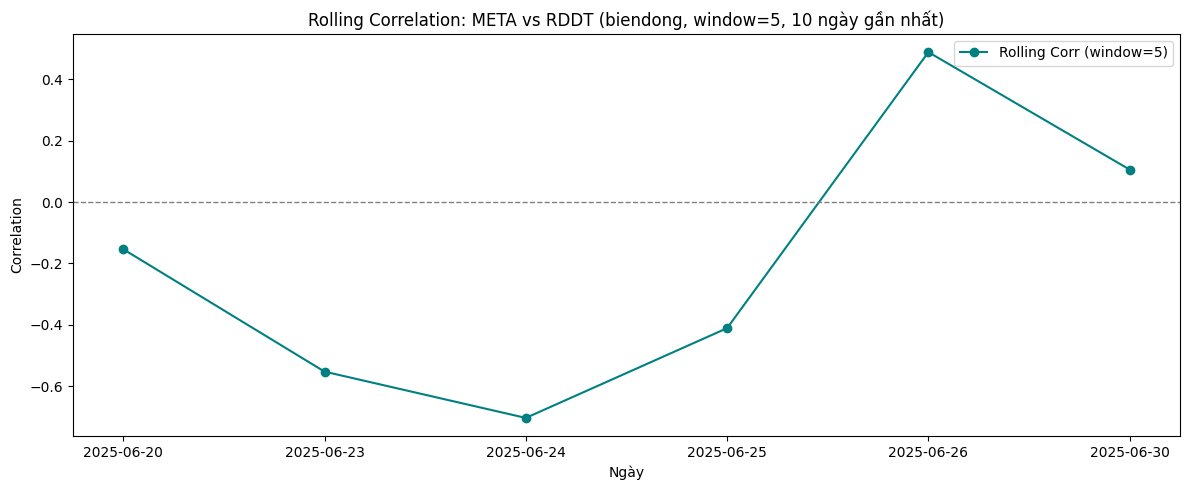

In [7]:
# 3. Rolling correlation (cửa sổ 5 ngày)
window = 5
rolling_corr = merged_10["biendong_META"].rolling(window).corr(merged_10["biendong_RDDT"])
plt.figure(figsize=(12, 5))
plt.plot(merged_10["Date"], rolling_corr, marker='o', color='teal', label=f'Rolling Corr (window={window})')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title(f'Rolling Correlation: META vs RDDT (biendong, window={window}, 10 ngày gần nhất)')
plt.xlabel('Ngày')
plt.ylabel('Correlation')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(compare_dir, 'rolling_corr_biendong.png'))
plt.show()
plt.close()

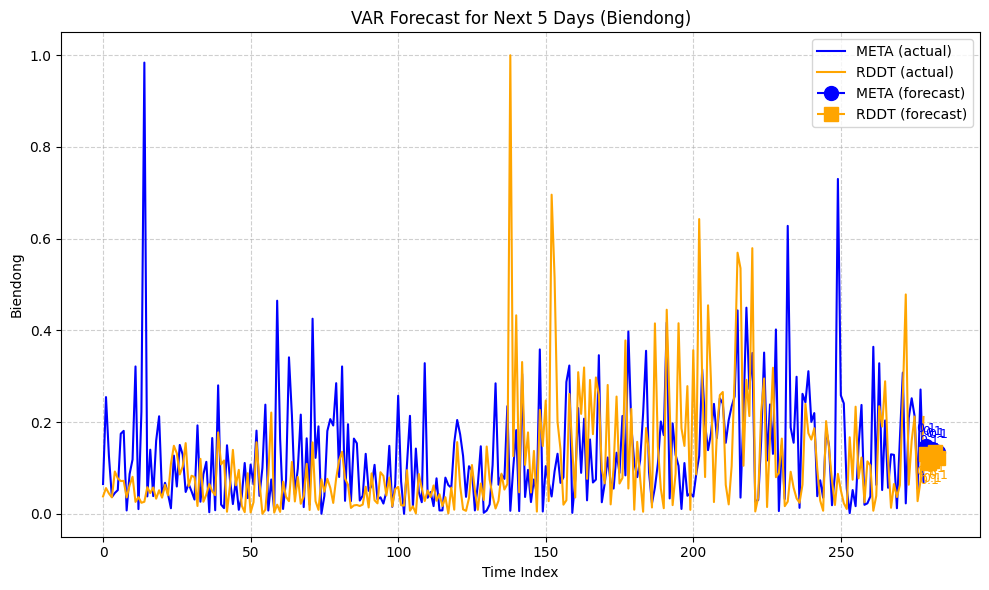

VAR forecast (META, RDDT):
[[0.14789094 0.12933999]
 [0.12214117 0.11049194]
 [0.14137169 0.11579535]
 [0.13789074 0.13555459]
 [0.13530103 0.12143807]]


In [8]:
# 4. VAR forecast (dự báo tương lai)
from statsmodels.tsa.api import VAR
var_df = merged[["biendong_META", "biendong_RDDT"]].replace([float('inf'), float('-inf')], pd.NA).dropna()
if len(var_df) >= 15:
    model = VAR(var_df)
    results = model.fit(maxlags=5, ic='aic')
    forecast = results.forecast(var_df.values[-results.k_ar:], steps=5)
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(var_df)), var_df["biendong_META"], label="META (actual)", color='blue')
    plt.plot(range(len(var_df)), var_df["biendong_RDDT"], label="RDDT (actual)", color='orange')
    plt.plot(range(len(var_df), len(var_df)+5), forecast[:,0], 'o--', label="META (forecast)", color='blue', markersize=10)
    plt.plot(range(len(var_df), len(var_df)+5), forecast[:,1], 's--', label="RDDT (forecast)", color='orange', markersize=10)
    for i in range(5):
        plt.annotate(f"{forecast[i,0]:.1f}", (len(var_df)+i, forecast[i,0]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='blue')
        plt.annotate(f"{forecast[i,1]:.1f}", (len(var_df)+i, forecast[i,1]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='orange')
    plt.title('VAR Forecast for Next 5 Days (Biendong)')
    plt.xlabel('Time Index')
    plt.ylabel('Biendong')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(compare_dir, 'var_forecast_biendong.png'))
    plt.show()
    plt.close()
    print('VAR forecast (META, RDDT):')
    print(forecast)
else:
    print(f"[VAR] Không đủ dữ liệu sạch để dự báo (còn lại {len(var_df)} dòng)")

In [9]:
print(f"Đã lưu các biểu đồ so sánh vào {compare_dir}")

Đã lưu các biểu đồ so sánh vào chart\5_visualization\compare
